# EDA

In [19]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from common.paths import get_data_raw_dpath
from common.logger import JUPYTER_LOGGER as logger

In [20]:
synth_df = pd.read_csv(get_data_raw_dpath() / 'mistral_judged_dataset.csv')
synth_df.head()

,dataset_name,query,correct_answer,model_answer,judge_score,is_hallucination
0,rubq-20,Какой стране принадлежит знаменитый остров Пасхи?,Чили,Чили.,не галлюцинация,0
1,rubq-20,С какой музыкальной группой неразрывно связано...,'Роллинг Стоунз',The Rolling Stones.,не галлюцинация,0
2,rubq-20,Где находится Летний сад?,Санкт-Петербург,"Летний сад находится в Санкт-Петербурге, Россия.",не галлюцинация,0
3,rubq-20,Какой город является столицей Туркмении?,Ашхабад,Ашхабад.,не галлюцинация,0
4,rubq-20,В каком городе издавалась с 1857 г. А. Герцено...,Лондон,"Газета ""Колокол"" издавалась в Лондоне.",не галлюцинация,0


C:\Users\User\AppData\Local\Temp\ipykernel_19212\164923396.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, palette='viridis')


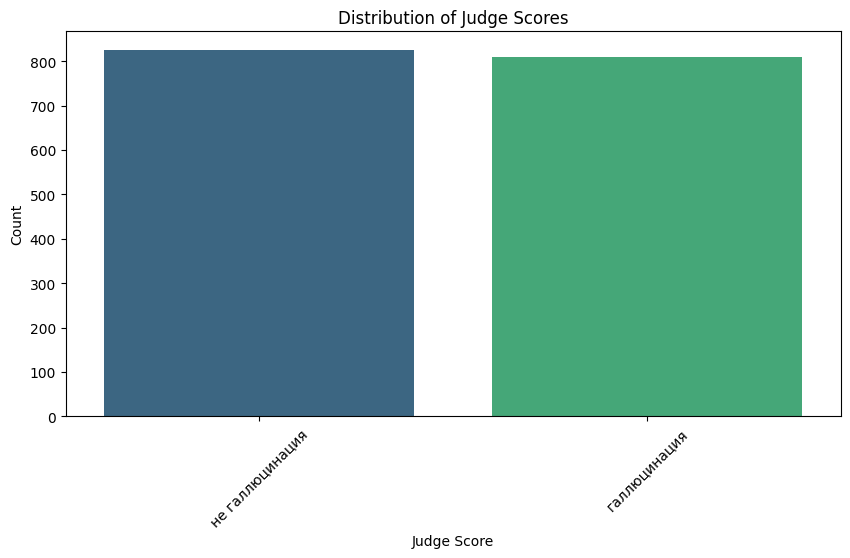

In [5]:
vc = synth_df['judge_score'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=vc.index, y=vc.values, palette='viridis')
plt.title('Distribution of Judge Scores')
plt.xlabel('Judge Score')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Concat with original dataset

In [33]:
original_df = pd.read_csv(get_data_raw_dpath() / 'features_with_judge_scores.csv')

common_cols = synth_df.columns.to_list()
common_cols.remove('dataset_name')

merged_df = pd.concat([original_df[common_cols], synth_df[common_cols]], ignore_index=True)
merged_df = merged_df.drop_duplicates(subset=['query']).reset_index(drop=True)
merged_df = merged_df.dropna(subset=['judge_score'])
merged_df['judge_score'] = merged_df['judge_score'].apply(
    lambda x: x == "галлюцинация" or x is True
)
logger.info(f'Merged dataset shape: {merged_df.shape}')
merged_df.head()

2026-04-05 01:40:38,409 - jupyter-notebooks - INFO - [JUPYTER 📓] Merged dataset shape: (2948, 5)


,query,correct_answer,model_answer,judge_score,is_hallucination
0,"ЭТОГО православного святого иногда называют ""м...",Федор УШАКОВ,Святого Николая Чудотворца иногда называют «мо...,True,1
1,"Где родился создатель музыки к фильму ""Крадено...",Каламата,Создателем музыки к фильму «Краденое небо» явл...,True,1
2,"Именно ему мы так верили, ""как, может быть, не...",Жириновскому,Эта фраза — цитата из романа Михаила Булгакова...,True,1
3,В этой знаменитой российской иерархии было 14 ...,"В ""Табели о рангах""","Вероятно, вы имеете в виду «Иерархию» — знамен...",True,1
4,"Согласно Большому толковому словарю, это — ""не...","Стопка. Зачет: Стопарь, стопарик",Это слово - *штоф*. \r\n\r\nШтоф — это небольш...,True,1


C:\Users\User\AppData\Local\Temp\ipykernel_19212\2397380612.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc_js_merged.index, y=vc_js_merged.values, palette='viridis')


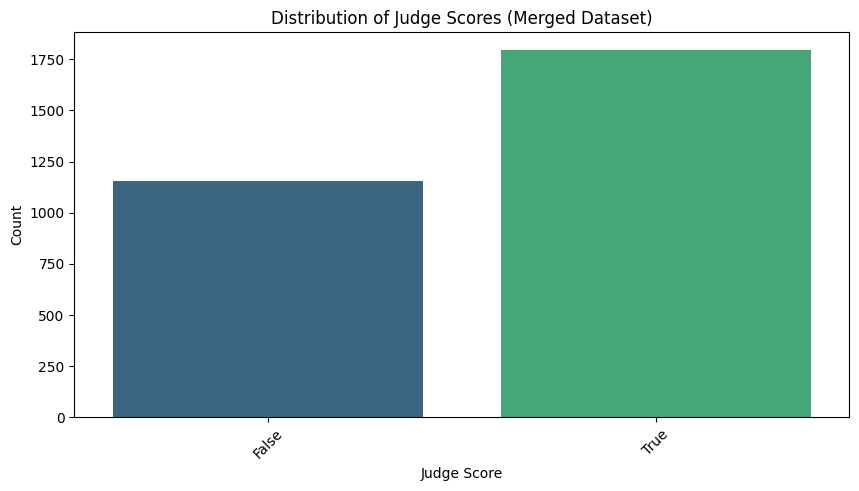

In [34]:
vc_js_merged = merged_df['judge_score'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=vc_js_merged.index, y=vc_js_merged.values, palette='viridis')
plt.title('Distribution of Judge Scores (Merged Dataset)')
plt.xlabel('Judge Score')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19212\1686442706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc_is_hallucination.index, y=vc_is_hallucination.values, palette='viridis')


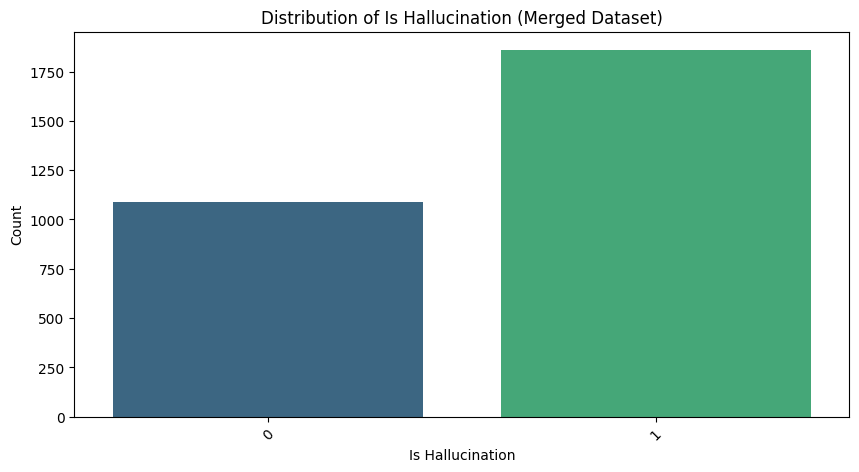

In [35]:
vc_is_hallucination = merged_df['is_hallucination'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=vc_is_hallucination.index, y=vc_is_hallucination.values, palette='viridis')
plt.title('Distribution of Is Hallucination (Merged Dataset)')
plt.xlabel('Is Hallucination')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()